prefix,A,M,C
0,225,224,210
1,249,232,210
2,251,234,210
3,217,234,210
4,222,212,240


prefix,A,M,C
0,66,60,60
1,42,52,60
2,40,50,60
3,74,50,60
4,69,72,30


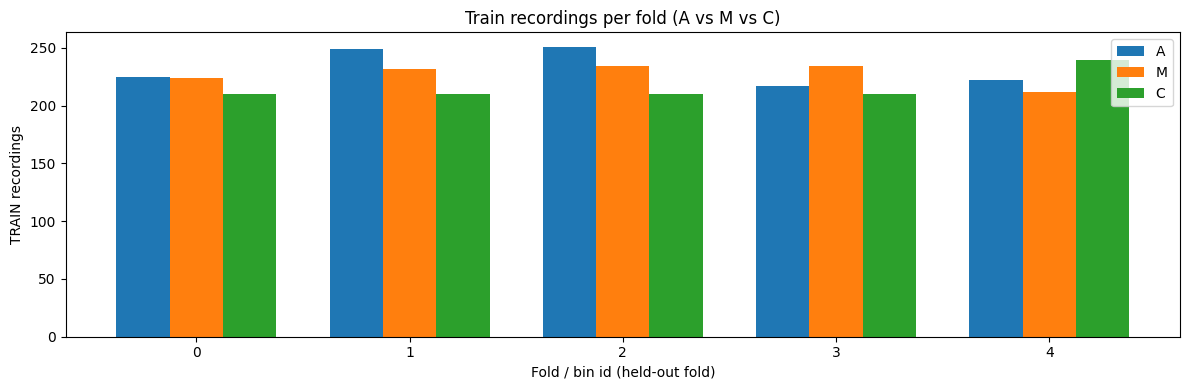

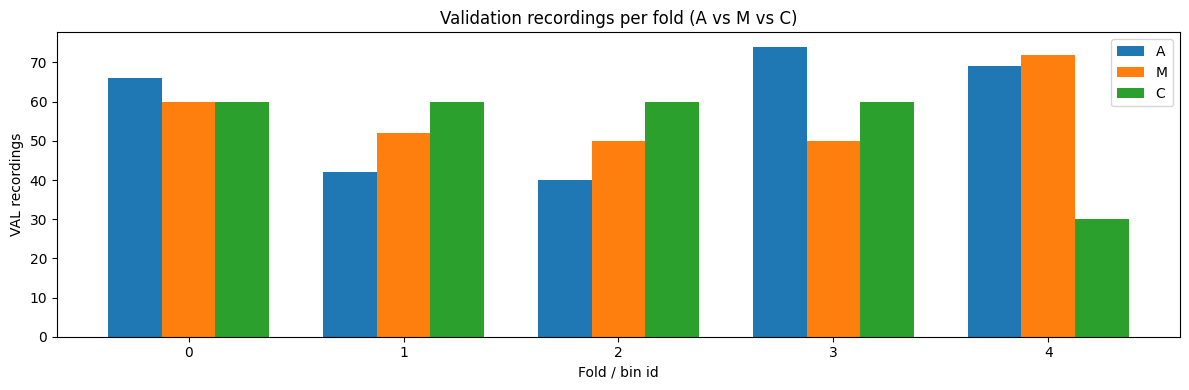

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

splits_dir = Path("../../data/emglab/splits_w400_h100")  # <-- change this
prefixes = ["A", "M", "C"]

# discover folds
fold_dirs = sorted([p for p in splits_dir.glob("fold_*") if p.is_dir()],
                   key=lambda p: int(p.name.split("_")[1]))
fold_ids = [int(p.name.split("_")[1]) for p in fold_dirs]

def load_split_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # ensure prefix exists
    if "prefix" not in df.columns:
        if "subject" in df.columns:
            df["prefix"] = df["subject"].astype(str).str[0]
        else:
            raise ValueError(f"No 'prefix' or 'subject' column in {path}")
    return df

train_counts = []
val_counts = []

for fdir, fid in zip(fold_dirs, fold_ids):
    df_tr = load_split_csv(fdir / "train.csv")
    df_va = load_split_csv(fdir / "val.csv")

    tr = df_tr.groupby("prefix").size().reindex(prefixes, fill_value=0)
    va = df_va.groupby("prefix").size().reindex(prefixes, fill_value=0)

    train_counts.append(tr)
    val_counts.append(va)

train_counts = pd.DataFrame(train_counts, index=fold_ids)  # rows: fold, cols: A/M/C
val_counts   = pd.DataFrame(val_counts,   index=fold_ids)

display(train_counts)
display(val_counts)

# ---- Plot Train ----
x = np.arange(len(fold_ids))
width = 0.25

plt.figure(figsize=(12, 4))
for i, p in enumerate(prefixes):
    plt.bar(x + (i-1)*width, train_counts[p].values, width=width, label=p)

plt.xticks(x, [str(f) for f in fold_ids])
plt.xlabel("Fold / bin id (held-out fold)")
plt.ylabel("TRAIN recordings")
plt.title("Train recordings per fold (A vs M vs C)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot Val ----
plt.figure(figsize=(12, 4))
for i, p in enumerate(prefixes):
    plt.bar(x + (i-1)*width, val_counts[p].values, width=width, label=p)

plt.xticks(x, [str(f) for f in fold_ids])
plt.xlabel("Fold / bin id")
plt.ylabel("VAL recordings")
plt.title("Validation recordings per fold (A vs M vs C)")
plt.legend()
plt.tight_layout()
plt.show()